# Mini projet Health-InsurTech 

Ce notebook couvre :
- le **nettoyage des données**
- la **modélisation interprétable**
- l'**évaluation du modèle**
- l'**analyse des biais**
- la **visualisation**
- la **sauvegarde des résultats**

Le dataset utilisé est `insurance_data.csv`.

## 1. Import des bibliothèques

In [16]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
import joblib

PROJECT_DIR = Path(".")
OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

DATA_PATH = PROJECT_DIR / "insurance_data.csv"

## 2. Chargement du dataset

In [17]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(1338, 22)


,id_client,nom,prenom,date_naissance,sexe,email,telephone,numero_secu_sociale,ville,code_postal,...,sex,bmi,children,smoker,region,charges,mutuelle_complementaire,adresse_ip,consentement_rgpd,date_inscription
0,CLI00001,Laurent,Cécile,04/11/2007,F,cecile.laurent@hotmail.fr,643842498,207116416078825,Bayonne,64100,...,female,27.900,0,yes,southwest,16884.92400,Maaf Santé,245.164.69.170,Oui,19/11/2018
1,CLI00002,Moulin,Guillaume,24/01/2008,M,guillaume_moulin46@gmail.com,682992299,108010691680375,Nice,6000,...,male,33.770,1,no,southeast,1725.55230,Groupama,57.173.29.88,Oui,12/11/2021
2,CLI00003,Joly,Frédéric,08/05/1998,M,fredericjoly@orange.fr,790010943,198050622504036,Antibes,6600,...,male,33.000,3,no,southeast,4449.46200,Aucune,227.165.135.149,Oui,19/06/2024
3,CLI00004,Labbé,Bernard,05/04/1993,M,bernard_labbe47@orange.fr,790784473,193042912782662,Quimper,29000,...,male,22.705,0,no,northwest,21984.47061,Harmonie Mutuelle,222.193.194.232,Oui,12/01/2020
4,CLI00005,Fernandez,Richard,04/12/1994,M,richard_fernandez@sfr.fr,747102767,194122966723622,Brest,29200,...,male,28.880,0,no,northwest,3866.85520,Matmut Santé,236.13.26.98,Non,17/08/2019


## 3. Nettoyage RGPD et préparation des données

On supprime les colonnes non nécessaires au modèle.

In [18]:
columns_to_drop = [
    "id_client", "nom", "prenom", "date_naissance", "email", "telephone",
    "numero_secu_sociale", "ville", "code_postal", "adresse_ip",
    "date_inscription", "sexe", "region_fr", "mutuelle_complementaire",
    "consentement_rgpd"
]

existing_cols_to_drop = [c for c in columns_to_drop if c in df.columns]
df_clean = df.drop(columns=existing_cols_to_drop).copy()

# Normalisation légère
if "sex" in df_clean.columns:
    df_clean["sex"] = df_clean["sex"].astype(str).str.strip().str.lower()
if "smoker" in df_clean.columns:
    df_clean["smoker"] = df_clean["smoker"].astype(str).str.strip().str.lower()
if "region" in df_clean.columns:
    df_clean["region"] = df_clean["region"].astype(str).str.strip().str.lower()

# Contraintes simples de qualité
if "age" in df_clean.columns:
    df_clean = df_clean[df_clean["age"].between(18, 100)]
if "bmi" in df_clean.columns:
    df_clean = df_clean[df_clean["bmi"].between(10, 60)]
if "children" in df_clean.columns:
    df_clean = df_clean[df_clean["children"].between(0, 10)]
if "charges" in df_clean.columns:
    df_clean = df_clean[df_clean["charges"] >= 0]

df_clean = df_clean.reset_index(drop=True)

print("Dimensions après nettoyage :", df_clean.shape)
df_clean.head()

Dimensions après nettoyage : (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 4. Vérification des valeurs manquantes

In [19]:
df_clean.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

## 5. Séparation variables explicatives / cible

In [20]:
X = df_clean.drop(columns=["charges"])
y = df_clean["charges"]

print("Colonnes explicatives :", list(X.columns))
print("Taille X :", X.shape)
print("Taille y :", y.shape)

Colonnes explicatives : ['age', 'sex', 'bmi', 'children', 'smoker', 'region']
Taille X : (1338, 6)
Taille y : (1338,)


## 6. Séparation train / test

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Train :", X_train.shape, y_train.shape)
print("Test  :", X_test.shape, y_test.shape)

Train : (1070, 6) (1070,)
Test  : (268, 6) (268,)


## 7. Prétraitement + modèle de régression linéaire

On utilise une **Pipeline** pour :
- imputer les éventuelles valeurs manquantes
- encoder les variables catégorielles
- entraîner un modèle interprétable

In [22]:
numeric_features = ["age", "bmi", "children"]
categorical_features = ["sex", "smoker", "region"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LinearRegression())
])

model.fit(X_train, y_train)
print("Modèle entraîné avec succès.")

Modèle entraîné avec succès.


## 8. Prédictions et évaluation

In [23]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

metrics = {
    "rows_after_cleaning": int(len(df_clean)),
    "train_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
    "mae": float(mae),
    "r2": float(r2)
}

print(json.dumps(metrics, indent=2, ensure_ascii=False))

{
  "rows_after_cleaning": 1338,
  "train_rows": 1070,
  "test_rows": 268,
  "mae": 4181.194473753651,
  "r2": 0.7835929767120724
}


* MAE= 4181 cad en moyenne, la prédiction du modèle se trompe d’environ 4181 unités monétaires sur les frais médicaux.
si les charges moyennes sont autour de 13000,une erreur de ≈4000 reste acceptable pour un modèle simple.
* R² = 0.7836
Le coefficient de détermination mesure la proportion de variance expliquée par le modèle,Donc :
le modèle explique 78.36% de la variation des frais médicaux
>Le modèle de régression linéaire obtient un coefficient de détermination R² = 0.78, ce qui signifie qu’il explique environ 78% de la variabilité des frais médicaux. L’erreur moyenne absolue (MAE ≈ 4181) indique que les prédictions peuvent s’écarter d’environ 4000 unités monétaires en moyenne. Ces résultats montrent que le modèle est globalement performant tout en restant interprétable, ce qui est cohérent avec l’objectif du projet. Toutefois, une analyse complémentaire des biais est nécessaire afin de vérifier que certaines catégories d’utilisateurs ne sont pas désavantagées par le modèle.

## 9. Interprétation des coefficients

Avec la régression linéaire, on peut interpréter l'effet de chaque variable.

In [24]:
onehot = model.named_steps["preprocess"].named_transformers_["cat"].named_steps["onehot"]
encoded_cat_features = onehot.get_feature_names_out(categorical_features).tolist()
all_features = numeric_features + encoded_cat_features

coef_df = pd.DataFrame({
    "feature": all_features,
    "coefficient": model.named_steps["model"].coef_
}).sort_values(by="coefficient", ascending=False)

coef_df

,feature,coefficient
4,smoker_yes,23651.128856
2,children,425.278784
1,bmi,337.092552
0,age,256.975706
3,sex_male,-18.591692
5,region_northwest,-370.677326
6,region_southeast,-657.864297
7,region_southwest,-809.799354


L’analyse des coefficients du modèle montre que le facteur le plus déterminant des frais médicaux est le statut de fumeur. En moyenne, un individu fumeur génère environ 23 651 unités monétaires de dépenses supplémentaires. L’âge et l’IMC ont également un impact positif sur les coûts médicaux, tandis que le nombre d’enfants influence modérément les dépenses. En revanche, le sexe n’a quasiment aucun effet dans le modèle. Les différences régionales restent relativement faibles. Ces résultats confirment que les comportements de santé, notamment le tabagisme, constituent les principaux déterminants des coûts médicaux dans le dataset.

## 10. Analyse des biais

On compare les erreurs moyennes par groupe :
- `smoker`
- `region`
- `sex`

In [25]:
eval_df = X_test.copy()
eval_df["actual_charges"] = y_test.values
eval_df["predicted_charges"] = y_pred
eval_df["absolute_error"] = (eval_df["actual_charges"] - eval_df["predicted_charges"]).abs()

def fairness_report(df_eval, group_col):
    return (
        df_eval.groupby(group_col)
        .agg(
            n=(group_col, "size"),
            mean_actual=("actual_charges", "mean"),
            mean_predicted=("predicted_charges", "mean"),
            mae=("absolute_error", "mean")
        )
        .reset_index()
        .sort_values("mae", ascending=False)
    )

fairness_smoker = fairness_report(eval_df, "smoker")
fairness_region = fairness_report(eval_df, "region")
fairness_sex = fairness_report(eval_df, "sex")

print("Biais par smoker")
display(fairness_smoker)

print("Biais par region")
display(fairness_region)

print("Biais par sex")
display(fairness_sex)

Biais par smoker


,smoker,n,mean_actual,mean_predicted,mae
1,yes,54,33204.104995,32761.744583,8348.079378
0,no,214,7862.090201,8248.276938,3129.737535


Biais par region


,region,n,mean_actual,mean_predicted,mae
2,southeast,81,14865.271559,16103.408981,5173.726392
0,northeast,57,13750.091863,13261.571175,3921.558727
3,southwest,61,11201.940833,11532.136419,3796.049705
1,northwest,69,11657.222458,11166.948787,3571.020316


Biais par sex


,sex,n,mean_actual,mean_predicted,mae
1,male,128,13719.691693,14219.769828,4671.886767
0,female,140,12281.345972,12243.820959,3732.561520


L’analyse des biais montre que le modèle présente une précision différente selon certains groupes. L’erreur moyenne est significativement plus élevée pour les fumeurs que pour les non-fumeurs, ce qui s’explique probablement par une plus grande variabilité des coûts médicaux dans ce groupe. Des différences plus modérées sont également observées entre certaines régions et entre les sexes, mais ces écarts restent limités. Afin de limiter ces biais, plusieurs solutions peuvent être envisagées, comme l’utilisation de modèles plus robustes, l’ajout de variables explicatives ou l’évaluation régulière des performances par sous-groupes.

## 11.corrélation entre âge, IMC et charges

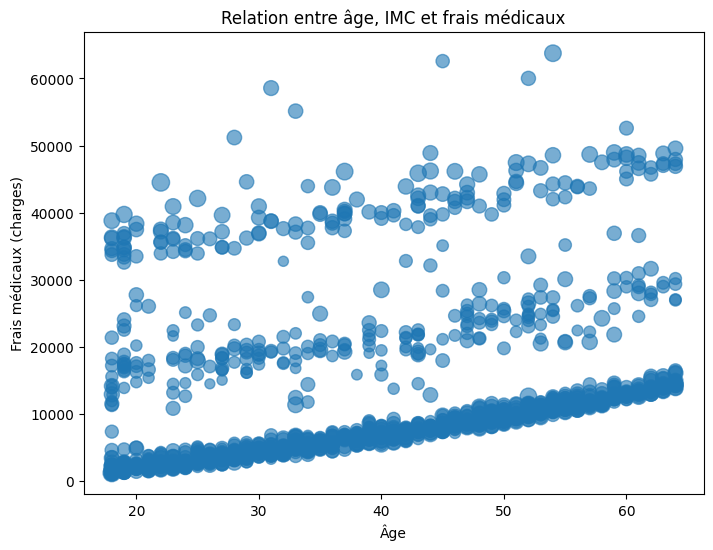

In [26]:
plot_df = df_clean.copy()

plt.figure(figsize=(8, 6))
scatter = plt.scatter(plot_df["age"], plot_df["charges"], s=plot_df["bmi"] * 3, alpha=0.6)
plt.xlabel("Âge")
plt.ylabel("Frais médicaux (charges)")
plt.title("Relation entre âge, IMC et frais médicaux")
plt.show()

Le graphique montre que la relation entre l’IMC et le niveau de glucose est globalement positive mais relativement dispersée. La régression linéaire (degré 1) capture la tendance générale, tandis que la régression polynomiale de degré 3 permet de modéliser une légère non-linéarité. En revanche, un modèle de degré 10 présente un risque de surapprentissage, car il s’ajuste trop fortement aux fluctuations des données. Ainsi, un modèle de complexité modérée constitue un meilleur compromis entre précision et capacité de généralisation.

In [27]:
import joblib

joblib.dump(model, "insurance_model.pkl")

['insurance_model.pkl']